In [1]:
import numpy as np
import pandas as pd
import time
import warnings

warnings.filterwarnings("ignore")

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

NumPy version: 2.5.1
Pandas version: 3.0.5


In [5]:
df = pd.read_csv("garments_worker_productivity.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

Dataset loaded successfully.
Shape: (1197, 15)
Dataset Shape: (1197, 15)

Column Names:
['date', 'quarter', 'department', 'day', 'team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'actual_productivity']

Data Types:
date                         str
quarter                      str
department                   str
day                          str
team                       int64
targeted_productivity    float64
smv                      float64
wip                      float64
over_time                  int64
incentive                  int64
idle_time                float64
idle_men                   int64
no_of_style_change         int64
no_of_workers            float64
actual_productivity      float64
dtype: object

First 5 Rows:


,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


In [6]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['date', 'quarter', 'department', 'day', 'team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'actual_productivity']


In [8]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
display(missing_values.to_frame("Missing Values"))

display(df.describe(include="all").T)

Missing values in each column:


,Missing Values
date,0
quarter,0
department,0
day,0
team,0
targeted_productivity,0
smv,0
wip,506
over_time,0
incentive,0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,1197,59,1/31/2015,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quarter,1197,5,Quarter1,360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
department,1197,3,sweing,691,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,1197,6,Wednesday,208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team,1197.0,NaN,NaN,NaN,6.426901,3.463963,1.0,3.0,6.0,9.0,12.0
targeted_productivity,1197.0,NaN,NaN,NaN,0.729632,0.097891,0.07,0.7,0.75,0.8,0.8
smv,1197.0,NaN,NaN,NaN,15.062172,10.943219,2.9,3.94,15.26,24.26,54.56
wip,691.0,NaN,NaN,NaN,1190.465991,1837.455001,7.0,774.5,1039.0,1252.5,23122.0
over_time,1197.0,NaN,NaN,NaN,4567.460317,3348.823563,0.0,1440.0,3960.0,6960.0,25920.0
incentive,1197.0,NaN,NaN,NaN,38.210526,160.182643,0.0,0.0,0.0,50.0,3600.0


In [9]:
for column in df.columns:
    print("\n" + "=" * 60)
    print(column)
    print("=" * 60)
    print(df[column].unique()[:20])


date
<ArrowStringArray>
[ '1/1/2015',  '1/3/2015',  '1/4/2015',  '1/5/2015',  '1/6/2015',  '1/7/2015',
  '1/8/2015', '1/10/2015', '1/11/2015', '1/12/2015', '1/13/2015', '1/14/2015',
 '1/15/2015', '1/17/2015', '1/18/2015', '1/19/2015', '1/20/2015', '1/21/2015',
 '1/22/2015', '1/24/2015']
Length: 20, dtype: str

quarter
<ArrowStringArray>
['Quarter1', 'Quarter2', 'Quarter3', 'Quarter4', 'Quarter5']
Length: 5, dtype: str

department
<ArrowStringArray>
['sweing', 'finishing ', 'finishing']
Length: 3, dtype: str

day
<ArrowStringArray>
['Thursday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday']
Length: 6, dtype: str

team
[ 8  1 11 12  6  7  2  3  9 10  5  4]

targeted_productivity
[0.8  0.75 0.7  0.65 0.6  0.35 0.5  0.07 0.4 ]

smv
[26.16  3.94 11.41 25.9  28.08 19.87 19.31  2.9  23.69  4.15 11.61 45.67
 21.98 31.83 12.52 42.41 20.79 50.48  4.3  22.4 ]

wip
[1108.   nan  968. 1170.  984.  795.  733.  681.  872.  578.  668.  861.
  772.  913. 1261.  844. 1005.  659. 1152. 1138.]



In [10]:
df["actual_productivity"] = pd.to_numeric(
    df["actual_productivity"], errors="coerce"
)

df["targeted_productivity"] = pd.to_numeric(
    df["targeted_productivity"], errors="coerce"
)

print(df[["actual_productivity", "targeted_productivity"]].dtypes)

actual_productivity      float64
targeted_productivity    float64
dtype: object


In [13]:
df["MeetsTarget"] = (
    df["actual_productivity"] >= df["targeted_productivity"]
).astype(int)

print("MeetsTarget distribution:")
print(df["MeetsTarget"].value_counts())

print("\nProportion:")
print(df["MeetsTarget"].value_counts(normalize=True))

display(
    df[
        [
            "targeted_productivity",
            "actual_productivity",
            "MeetsTarget"
        ]
    ].head(15)
)

if "date" in df.columns:
    df = df.drop(columns=["date"])

print(df.columns.tolist())

MeetsTarget distribution:
MeetsTarget
1    875
0    322
Name: count, dtype: int64

Proportion:
MeetsTarget
1    0.730994
0    0.269006
Name: proportion, dtype: float64


,targeted_productivity,actual_productivity,MeetsTarget
0,0.80,0.940725,1
1,0.75,0.886500,1
2,0.80,0.800570,1
3,0.80,0.800570,1
4,0.80,0.800382,1
5,0.80,0.800125,1
6,0.75,0.755167,1
7,0.75,0.753683,1
8,0.75,0.753098,1
9,0.75,0.750428,1


['quarter', 'department', 'day', 'team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'actual_productivity', 'MeetsTarget']


In [14]:
target_regression = "actual_productivity"
target_classification = "MeetsTarget"

# Remove both target columns from features
feature_columns = [
    col for col in df.columns
    if col not in ["actual_productivity", "MeetsTarget"]
]

X = df[feature_columns].copy()

y_reg = df["actual_productivity"].copy()
y_cls = df["MeetsTarget"].copy()

print("Features:")
print(feature_columns)

print("\nNumber of features:", len(feature_columns))
print("Regression target:", target_regression)
print("Classification target:", target_classification)

Features:
['quarter', 'department', 'day', 'team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers']

Number of features: 13
Regression target: actual_productivity
Classification target: MeetsTarget


In [15]:
print("Numerical columns:")

numeric_columns = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

print(numeric_columns)

print("\nCategorical columns:")

categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(categorical_columns)

Numerical columns:
['team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers']

Categorical columns:
['quarter', 'department', 'day']


In [16]:
from sklearn.model_selection import train_test_split

# Create indices so exactly the same rows can be reused
indices = np.arange(len(df))

train_indices, test_indices = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    shuffle=True,
    stratify=y_cls
)

print("Training samples:", len(train_indices))
print("Testing samples:", len(test_indices))

Training samples: 957
Testing samples: 240


In [17]:
X_train = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()

y_reg_train = y_reg.iloc[train_indices].copy()
y_reg_test = y_reg.iloc[test_indices].copy()

y_cls_train = y_cls.iloc[train_indices].copy()
y_cls_test = y_cls.iloc[test_indices].copy()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\ny_reg_train:", y_reg_train.shape)
print("y_reg_test :", y_reg_test.shape)

print("\ny_cls_train:", y_cls_train.shape)
print("y_cls_test :", y_cls_test.shape)

X_train: (957, 13)
X_test : (240, 13)

y_reg_train: (957,)
y_reg_test : (240,)

y_cls_train: (957,)
y_cls_test : (240,)


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print("Scikit-learn preprocessing imported.")
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_columns),
    ("categorical", categorical_pipeline, categorical_columns)
])

print("Preprocessing pipeline created.")

Scikit-learn preprocessing imported.
Preprocessing pipeline created.


In [19]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

print(linear_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['team',
                                                   'targeted_productivity',
                                                   'smv', 'wip', 'over_time',
                                                   'incentive', 'idle_time',
                                                   'idle_men',
                                                   'no_of_style_change',
                                                   'no_of_workers']),
                                                 ('categorical',


In [20]:
start_time = time.perf_counter()

linear_model.fit(X_train, y_reg_train)

reg_training_time_sklearn = time.perf_counter() - start_time

print(
    f"Linear Regression training time: "
    f"{reg_training_time_sklearn:.6f} seconds"
)

Linear Regression training time: 0.022482 seconds


In [23]:
start_time = time.perf_counter()

y_reg_pred_sklearn = linear_model.predict(X_test)

reg_prediction_time_sklearn = time.perf_counter() - start_time

print(
    f"Linear Regression prediction time: "
    f"{reg_prediction_time_sklearn:.6f} seconds"
)

print("\nFirst 10 predictions:")
print(y_reg_pred_sklearn[:10])

Linear Regression prediction time: 0.008798 seconds

First 10 predictions:
[0.83653561 0.7075372  0.78752045 0.63881458 0.73453934 0.75485423
 0.67627679 0.79155521 0.74639686 0.78273093]


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

reg_mae_sklearn = mean_absolute_error(
    y_reg_test,
    y_reg_pred_sklearn
)

reg_rmse_sklearn = np.sqrt(
    mean_squared_error(
        y_reg_test,
        y_reg_pred_sklearn
    )
)

reg_r2_sklearn = r2_score(
    y_reg_test,
    y_reg_pred_sklearn
)

print("Scikit-learn Linear Regression")
print("-" * 40)
print(f"MAE  : {reg_mae_sklearn:.6f}")
print(f"RMSE : {reg_rmse_sklearn:.6f}")
print(f"R²   : {reg_r2_sklearn:.6f}")

Scikit-learn Linear Regression
----------------------------------------
MAE  : 0.107278
RMSE : 0.143740
R²   : 0.288521


In [25]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

print(logistic_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['team',
                                                   'targeted_productivity',
                                                   'smv', 'wip', 'over_time',
                                                   'incentive', 'idle_time',
                                                   'idle_men',
                                                   'no_of_style_change',
                                                   'no_of_workers']),
                                                 ('categorical',


In [27]:
start_time = time.perf_counter()

logistic_model.fit(X_train, y_cls_train)

cls_training_time_sklearn = time.perf_counter() - start_time

print(
    f"Logistic Regression training time: "
    f"{cls_training_time_sklearn:.6f} seconds"
)

Logistic Regression training time: 0.029271 seconds


In [28]:
start_time = time.perf_counter()

y_cls_pred_sklearn = logistic_model.predict(X_test)

cls_prediction_time_sklearn = time.perf_counter() - start_time

print(
    f"Logistic Regression prediction time: "
    f"{cls_prediction_time_sklearn:.6f} seconds"
)

print("\nFirst 20 predictions:")
print(y_cls_pred_sklearn[:20])

Logistic Regression prediction time: 0.008985 seconds

First 20 predictions:
[1 1 1 0 1 1 1 1 1 0 0 1 1 1 0 1 1 1 1 1]


In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

cls_accuracy_sklearn = accuracy_score(
    y_cls_test,
    y_cls_pred_sklearn
)

cls_precision_sklearn = precision_score(
    y_cls_test,
    y_cls_pred_sklearn,
    zero_division=0
)

cls_recall_sklearn = recall_score(
    y_cls_test,
    y_cls_pred_sklearn,
    zero_division=0
)

cls_f1_sklearn = f1_score(
    y_cls_test,
    y_cls_pred_sklearn,
    zero_division=0
)

print("Scikit-learn Logistic Regression")
print("-" * 40)
print(f"Accuracy  : {cls_accuracy_sklearn:.6f}")
print(f"Precision : {cls_precision_sklearn:.6f}")
print(f"Recall    : {cls_recall_sklearn:.6f}")
print(f"F1-score  : {cls_f1_sklearn:.6f}")

Scikit-learn Logistic Regression
----------------------------------------
Accuracy  : 0.708333
Precision : 0.761194
Recall    : 0.874286
F1-score  : 0.813830


In [30]:
X_manual = X.copy()

X_manual_train = X_manual.iloc[train_indices].copy()
X_manual_test = X_manual.iloc[test_indices].copy()

print("Manual training data:", X_manual_train.shape)
print("Manual testing data :", X_manual_test.shape)

Manual training data: (957, 13)
Manual testing data : (240, 13)


In [31]:
def manual_fill_missing(train_df, test_df):
    train_df = train_df.copy()
    test_df = test_df.copy()

    numeric_cols = train_df.select_dtypes(
        include=["int64", "float64", "int32", "float32"]
    ).columns

    categorical_cols = train_df.select_dtypes(
        include=["object", "category"]
    ).columns

    # Numeric: use training median
    for col in numeric_cols:
        median_value = train_df[col].median()

        train_df[col] = train_df[col].fillna(median_value)
        test_df[col] = test_df[col].fillna(median_value)

    # Categorical: use training mode
    for col in categorical_cols:
        mode_value = train_df[col].mode()[0]

        train_df[col] = train_df[col].fillna(mode_value)
        test_df[col] = test_df[col].fillna(mode_value)

    return train_df, test_df


X_manual_train, X_manual_test = manual_fill_missing(
    X_manual_train,
    X_manual_test
)

print("Missing values after manual handling:")
print(X_manual_train.isnull().sum().sum())
print(X_manual_test.isnull().sum().sum())

Missing values after manual handling:
0
0


In [33]:
def manual_one_hot_encode(train_df, test_df):
    combined = pd.concat(
        [train_df, test_df],
        axis=0
    )

    combined_encoded = pd.get_dummies(
        combined,
        columns=categorical_columns,
        drop_first=False,
        dtype=float
    )

    train_encoded = combined_encoded.iloc[:len(train_df)].copy()
    test_encoded = combined_encoded.iloc[len(train_df):].copy()

    return train_encoded, test_encoded


X_manual_train_encoded, X_manual_test_encoded = manual_one_hot_encode(
    X_manual_train,
    X_manual_test
)

print("Encoded training shape:", X_manual_train_encoded.shape)
print("Encoded testing shape :", X_manual_test_encoded.shape)

X_manual_train_encoded = X_manual_train_encoded.astype(float)
X_manual_test_encoded = X_manual_test_encoded.astype(float)

print(X_manual_train_encoded.dtypes.value_counts())

Encoded training shape: (957, 24)
Encoded testing shape : (240, 24)
float64    24
Name: count, dtype: int64


In [34]:
def manual_standardize(X_train, X_test):
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)

    # Prevent division by zero
    std = std.replace(0, 1)

    X_train_scaled = (X_train - mean) / std
    X_test_scaled = (X_test - mean) / std

    return (
        X_train_scaled,
        X_test_scaled,
        mean,
        std
    )


X_manual_train_scaled, X_manual_test_scaled, manual_mean, manual_std = (
    manual_standardize(
        X_manual_train_encoded,
        X_manual_test_encoded
    )
)

print("Manual scaling completed.")

Manual scaling completed.


In [35]:
X_train_np = X_manual_train_scaled.to_numpy()
X_test_np = X_manual_test_scaled.to_numpy()

y_reg_train_np = y_reg_train.to_numpy()
y_reg_test_np = y_reg_test.to_numpy()

y_cls_train_np = y_cls_train.to_numpy()
y_cls_test_np = y_cls_test.to_numpy()

print("X_train:", X_train_np.shape)
print("X_test :", X_test_np.shape)

X_train: (957, 24)
X_test : (240, 24)


In [37]:
def add_intercept(X):
    return np.c_[
        np.ones(X.shape[0]),
        X
    ]


X_train_bias = add_intercept(X_train_np)
X_test_bias = add_intercept(X_test_np)

print("X_train with intercept:", X_train_bias.shape)
print("X_test with intercept :", X_test_bias.shape)

def manual_linear_regression_fit(X, y):
    beta = np.linalg.pinv(X.T @ X) @ X.T @ y
    return beta


def manual_linear_regression_predict(X, beta):
    return X @ beta

X_train with intercept: (957, 25)
X_test with intercept : (240, 25)


In [38]:
start_time = time.perf_counter()

beta = manual_linear_regression_fit(
    X_train_bias,
    y_reg_train_np
)

reg_training_time_manual = time.perf_counter() - start_time

print(
    f"Manual Linear Regression training time: "
    f"{reg_training_time_manual:.6f} seconds"
)

Manual Linear Regression training time: 0.001649 seconds


In [39]:
start_time = time.perf_counter()

y_reg_pred_manual = manual_linear_regression_predict(
    X_test_bias,
    beta
)

reg_prediction_time_manual = time.perf_counter() - start_time

print(
    f"Manual Linear Regression prediction time: "
    f"{reg_prediction_time_manual:.6f} seconds"
)

print("\nFirst 10 predictions:")
print(y_reg_pred_manual[:10])

Manual Linear Regression prediction time: 0.000086 seconds

First 10 predictions:
[0.83653561 0.7075372  0.78752045 0.63881458 0.73453934 0.75485423
 0.67627679 0.79155521 0.74639686 0.78273093]


In [40]:
def manual_mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def manual_rmse(y_true, y_pred):
    return np.sqrt(
        np.mean((y_true - y_pred) ** 2)
    )


def manual_r2(y_true, y_pred):
    ss_res = np.sum(
        (y_true - y_pred) ** 2
    )

    ss_total = np.sum(
        (y_true - np.mean(y_true)) ** 2
    )

    return 1 - (ss_res / ss_total)

In [42]:
reg_mae_manual = manual_mae(
    y_reg_test_np,
    y_reg_pred_manual
)

reg_rmse_manual = manual_rmse(
    y_reg_test_np,
    y_reg_pred_manual
)

reg_r2_manual = manual_r2(
    y_reg_test_np,
    y_reg_pred_manual
)

print("Manual Linear Regression")
print("-" * 40)
print(f"MAE  : {reg_mae_manual:.6f}")
print(f"RMSE : {reg_rmse_manual:.6f}")
print(f"R²   : {reg_r2_manual:.6f}")

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

Manual Linear Regression
----------------------------------------
MAE  : 0.107278
RMSE : 0.143740
R²   : 0.288521


In [43]:
def manual_logistic_regression(
    X,
    y,
    learning_rate=0.01,
    iterations=10000,
    tolerance=1e-7
):
    
    n_samples, n_features = X.shape
    
    weights = np.zeros(n_features)
    bias = 0.0
    
    previous_loss = float("inf")
    
    for i in range(iterations):
        
        # Linear combination
        z = X @ weights + bias
        
        # Probability
        probabilities = sigmoid(z)
        
        # Errors
        error = probabilities - y
        
        # Gradients
        dw = (X.T @ error) / n_samples
        db = np.mean(error)
        
        # Update parameters
        weights -= learning_rate * dw
        bias -= learning_rate * db
        
        # Binary cross entropy loss
        eps = 1e-15
        
        p = np.clip(
            probabilities,
            eps,
            1 - eps
        )
        
        loss = -np.mean(
            y * np.log(p) +
            (1 - y) * np.log(1 - p)
        )
        
        # Convergence check
        if abs(previous_loss - loss) < tolerance:
            break
        
        previous_loss = loss
    
    return weights, bias, i + 1, loss

In [48]:
start_time = time.perf_counter()

logistic_weights, logistic_bias, iterations_used, final_loss = (
    manual_logistic_regression(
        X_train_np,
        y_cls_train_np,
        learning_rate=0.01,
        iterations=10000,
        tolerance=1e-7
    )
)

cls_training_time_manual = time.perf_counter() - start_time

print(
    f"Manual Logistic Regression training time: "
    f"{cls_training_time_manual:.6f} seconds"
)

print("Iterations used:", iterations_used)
print("Final loss:", final_loss)

def manual_logistic_predict_proba(
    X,
    weights,
    bias
):
    return sigmoid(
        X @ weights + bias
    )

Manual Logistic Regression training time: 0.402313 seconds
Iterations used: 10000
Final loss: 0.48231339510128035


In [49]:
def manual_logistic_predict(
    X,
    weights,
    bias,
    threshold=0.5
):
    probabilities = manual_logistic_predict_proba(
        X,
        weights,
        bias
    )
    
    predictions = (
        probabilities >= threshold
    ).astype(int)
    
    return predictions

In [50]:
start_time = time.perf_counter()

y_cls_pred_manual = manual_logistic_predict(
    X_test_np,
    logistic_weights,
    logistic_bias,
    threshold=0.5
)

cls_prediction_time_manual = time.perf_counter() - start_time

print(
    f"Manual Logistic Regression prediction time: "
    f"{cls_prediction_time_manual:.6f} seconds"
)

print("\nFirst 20 predictions:")
print(y_cls_pred_manual[:20])

Manual Logistic Regression prediction time: 0.000253 seconds

First 20 predictions:
[1 1 1 0 1 1 1 1 1 0 0 1 1 1 0 1 1 1 1 1]


In [51]:
def manual_confusion_values(y_true, y_pred):
    
    tp = np.sum(
        (y_true == 1) & (y_pred == 1)
    )
    
    tn = np.sum(
        (y_true == 0) & (y_pred == 0)
    )
    
    fp = np.sum(
        (y_true == 0) & (y_pred == 1)
    )
    
    fn = np.sum(
        (y_true == 1) & (y_pred == 0)
    )
    
    return tp, tn, fp, fn


def manual_accuracy(y_true, y_pred):
    tp, tn, fp, fn = manual_confusion_values(
        y_true,
        y_pred
    )
    
    return (tp + tn) / (tp + tn + fp + fn)


def manual_precision(y_true, y_pred):
    tp, tn, fp, fn = manual_confusion_values(
        y_true,
        y_pred
    )
    
    denominator = tp + fp
    
    if denominator == 0:
        return 0
    
    return tp / denominator


def manual_recall(y_true, y_pred):
    tp, tn, fp, fn = manual_confusion_values(
        y_true,
        y_pred
    )
    
    denominator = tp + fn
    
    if denominator == 0:
        return 0
    
    return tp / denominator


def manual_f1(y_true, y_pred):
    precision = manual_precision(
        y_true,
        y_pred
    )
    
    recall = manual_recall(
        y_true,
        y_pred
    )
    
    denominator = precision + recall
    
    if denominator == 0:
        return 0
    
    return (
        2 * precision * recall
    ) / denominator

In [52]:
cls_accuracy_manual = manual_accuracy(
    y_cls_test_np,
    y_cls_pred_manual
)

cls_precision_manual = manual_precision(
    y_cls_test_np,
    y_cls_pred_manual
)

cls_recall_manual = manual_recall(
    y_cls_test_np,
    y_cls_pred_manual
)

cls_f1_manual = manual_f1(
    y_cls_test_np,
    y_cls_pred_manual
)

print("Manual Logistic Regression")
print("-" * 40)
print(f"Accuracy  : {cls_accuracy_manual:.6f}")
print(f"Precision : {cls_precision_manual:.6f}")
print(f"Recall    : {cls_recall_manual:.6f}")
print(f"F1-score  : {cls_f1_manual:.6f}")

tp, tn, fp, fn = manual_confusion_values(
    y_cls_test_np,
    y_cls_pred_manual
)

print("Confusion Matrix Values")
print("-" * 30)
print("True Positive :", tp)
print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)

Manual Logistic Regression
----------------------------------------
Accuracy  : 0.712500
Precision : 0.765000
Recall    : 0.874286
F1-score  : 0.816000
Confusion Matrix Values
------------------------------
True Positive : 153
True Negative : 18
False Positive: 47
False Negative: 22


In [53]:
regression_results = pd.DataFrame({
    "Implementation": [
        "Scikit-learn",
        "Manual NumPy/Pandas"
    ],
    "MAE": [
        reg_mae_sklearn,
        reg_mae_manual
    ],
    "RMSE": [
        reg_rmse_sklearn,
        reg_rmse_manual
    ],
    "R2": [
        reg_r2_sklearn,
        reg_r2_manual
    ],
    "Training Time (s)": [
        reg_training_time_sklearn,
        reg_training_time_manual
    ],
    "Prediction Time (s)": [
        reg_prediction_time_sklearn,
        reg_prediction_time_manual
    ]
})

display(
    regression_results.round(6)
)

,Implementation,MAE,RMSE,R2,Training Time (s),Prediction Time (s)
0,Scikit-learn,0.107278,0.14374,0.288521,0.012404,0.008798
1,Manual NumPy/Pandas,0.107278,0.14374,0.288521,0.001649,0.000086


In [54]:
classification_results = pd.DataFrame({
    "Implementation": [
        "Scikit-learn",
        "Manual NumPy/Pandas"
    ],
    "Accuracy": [
        cls_accuracy_sklearn,
        cls_accuracy_manual
    ],
    "Precision": [
        cls_precision_sklearn,
        cls_precision_manual
    ],
    "Recall": [
        cls_recall_sklearn,
        cls_recall_manual
    ],
    "F1": [
        cls_f1_sklearn,
        cls_f1_manual
    ],
    "Training Time (s)": [
        cls_training_time_sklearn,
        cls_training_time_manual
    ],
    "Prediction Time (s)": [
        cls_prediction_time_sklearn,
        cls_prediction_time_manual
    ]
})

display(
    classification_results.round(6)
)

,Implementation,Accuracy,Precision,Recall,F1,Training Time (s),Prediction Time (s)
0,Scikit-learn,0.708333,0.761194,0.874286,0.81383,0.029271,0.008985
1,Manual NumPy/Pandas,0.712500,0.765000,0.874286,0.81600,0.402313,0.000253


In [55]:
prediction_comparison = pd.DataFrame({
    "Actual Productivity": y_reg_test_np[:10],
    "Sklearn Prediction": y_reg_pred_sklearn[:10],
    "Manual Prediction": y_reg_pred_manual[:10]
})

display(
    prediction_comparison.round(4)
)

,Actual Productivity,Sklearn Prediction,Manual Prediction
0,0.6019,0.8365,0.8365
1,0.7506,0.7075,0.7075
2,0.6497,0.7875,0.7875
3,0.5795,0.6388,0.6388
4,0.5865,0.7345,0.7345
5,0.8001,0.7549,0.7549
6,0.5047,0.6763,0.6763
7,0.9618,0.7916,0.7916
8,0.8740,0.7464,0.7464
9,0.7859,0.7827,0.7827


In [56]:
classification_prediction_comparison = pd.DataFrame({
    "Actual MeetsTarget": y_cls_test_np[:20],
    "Sklearn Prediction": y_cls_pred_sklearn[:20],
    "Manual Prediction": y_cls_pred_manual[:20]
})

display(
    classification_prediction_comparison
)

,Actual MeetsTarget,Sklearn Prediction,Manual Prediction
0,0,1,1
1,1,1,1
2,0,1,1
3,0,0,0
4,0,1,1
5,1,1,1
6,0,1,1
7,1,1,1
8,1,1,1
9,0,0,0


In [57]:
def optimized_logistic_regression(
    X,
    y,
    learning_rate=0.01,
    iterations=15000,
    regularization=0.001,
    tolerance=1e-8
):
    
    n_samples, n_features = X.shape
    
    weights = np.zeros(n_features)
    bias = 0.0
    
    previous_loss = float("inf")
    
    for i in range(iterations):
        
        z = X @ weights + bias
        
        probabilities = sigmoid(z)
        
        error = probabilities - y
        
        # L2 regularization gradient
        dw = (
            (X.T @ error) / n_samples
            + regularization * weights
        )
        
        db = np.mean(error)
        
        weights -= learning_rate * dw
        bias -= learning_rate * db
        
        eps = 1e-15
        
        p = np.clip(
            probabilities,
            eps,
            1 - eps
        )
        
        # Regularized loss
        loss = (
            -np.mean(
                y * np.log(p)
                + (1 - y) * np.log(1 - p)
            )
            + (regularization / 2)
            * np.sum(weights ** 2)
        )
        
        if abs(previous_loss - loss) < tolerance:
            break
        
        previous_loss = loss
    
    return weights, bias, i + 1, loss

In [58]:
learning_rates = [
    0.001,
    0.005,
    0.01,
    0.05,
    0.1
]

optimization_results = []

for lr in learning_rates:
    
    start_time = time.perf_counter()
    
    weights_opt, bias_opt, iterations_opt, loss_opt = (
        optimized_logistic_regression(
            X_train_np,
            y_cls_train_np,
            learning_rate=lr,
            iterations=15000,
            regularization=0.001
        )
    )
    
    training_time = time.perf_counter() - start_time
    
    predictions = manual_logistic_predict(
        X_test_np,
        weights_opt,
        bias_opt
    )
    
    accuracy = manual_accuracy(
        y_cls_test_np,
        predictions
    )
    
    precision = manual_precision(
        y_cls_test_np,
        predictions
    )
    
    recall = manual_recall(
        y_cls_test_np,
        predictions
    )
    
    f1 = manual_f1(
        y_cls_test_np,
        predictions
    )
    
    optimization_results.append({
        "Learning Rate": lr,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Iterations": iterations_opt,
        "Loss": loss_opt,
        "Training Time": training_time
    })

optimization_df = pd.DataFrame(
    optimization_results
)

display(
    optimization_df.round(6)
)

,Learning Rate,Accuracy,Precision,Recall,F1,Iterations,Loss,Training Time
0,0.001,0.745833,0.771429,0.925714,0.841558,15000,0.502510,0.665189
1,0.005,0.708333,0.758621,0.880000,0.814815,15000,0.485139,0.720077
2,0.010,0.708333,0.763819,0.868571,0.812834,15000,0.483370,0.794521
3,0.050,0.712500,0.765000,0.874286,0.816000,7735,0.482916,0.377431
4,0.100,0.712500,0.765000,0.874286,0.816000,4350,0.482909,0.196635


In [59]:
best_index = optimization_df["F1"].idxmax()

best_result = optimization_df.loc[best_index]

best_learning_rate = best_result["Learning Rate"]

print("Best learning rate based on F1-score:")
print(best_learning_rate)

print("\nBest result:")
display(
    best_result.to_frame("Value")
)

Best learning rate based on F1-score:
0.001

Best result:


,Value
Learning Rate,0.001000
Accuracy,0.745833
Precision,0.771429
Recall,0.925714
F1,0.841558
Iterations,15000.000000
Loss,0.502510
Training Time,0.665189


In [60]:
start_time = time.perf_counter()

optimized_weights, optimized_bias, optimized_iterations, optimized_loss = (
    optimized_logistic_regression(
        X_train_np,
        y_cls_train_np,
        learning_rate=float(best_learning_rate),
        iterations=15000,
        regularization=0.001
    )
)

optimized_training_time = time.perf_counter() - start_time

print(
    f"Optimized training time: "
    f"{optimized_training_time:.6f} seconds"
)

print("Iterations:", optimized_iterations)
print("Final loss:", optimized_loss)

Optimized training time: 0.665544 seconds
Iterations: 15000
Final loss: 0.5025103988224708


In [61]:
start_time = time.perf_counter()

y_cls_pred_optimized = manual_logistic_predict(
    X_test_np,
    optimized_weights,
    optimized_bias
)

optimized_prediction_time = time.perf_counter() - start_time

print(
    f"Optimized prediction time: "
    f"{optimized_prediction_time:.6f} seconds"
)

Optimized prediction time: 0.000147 seconds


In [62]:
optimized_accuracy = manual_accuracy(
    y_cls_test_np,
    y_cls_pred_optimized
)

optimized_precision = manual_precision(
    y_cls_test_np,
    y_cls_pred_optimized
)

optimized_recall = manual_recall(
    y_cls_test_np,
    y_cls_pred_optimized
)

optimized_f1 = manual_f1(
    y_cls_test_np,
    y_cls_pred_optimized
)

print("Optimized Manual Logistic Regression")
print("-" * 45)
print(f"Accuracy  : {optimized_accuracy:.6f}")
print(f"Precision : {optimized_precision:.6f}")
print(f"Recall    : {optimized_recall:.6f}")
print(f"F1-score  : {optimized_f1:.6f}")

Optimized Manual Logistic Regression
---------------------------------------------
Accuracy  : 0.745833
Precision : 0.771429
Recall    : 0.925714
F1-score  : 0.841558


In [63]:
final_classification_results = pd.DataFrame({
    "Implementation": [
        "Scikit-learn",
        "Manual",
        "Optimized Manual"
    ],
    "Accuracy": [
        cls_accuracy_sklearn,
        cls_accuracy_manual,
        optimized_accuracy
    ],
    "Precision": [
        cls_precision_sklearn,
        cls_precision_manual,
        optimized_precision
    ],
    "Recall": [
        cls_recall_sklearn,
        cls_recall_manual,
        optimized_recall
    ],
    "F1": [
        cls_f1_sklearn,
        cls_f1_manual,
        optimized_f1
    ],
    "Training Time (s)": [
        cls_training_time_sklearn,
        cls_training_time_manual,
        optimized_training_time
    ],
    "Prediction Time (s)": [
        cls_prediction_time_sklearn,
        cls_prediction_time_manual,
        optimized_prediction_time
    ]
})

display(
    final_classification_results.round(6)
)

,Implementation,Accuracy,Precision,Recall,F1,Training Time (s),Prediction Time (s)
0,Scikit-learn,0.708333,0.761194,0.874286,0.813830,0.029271,0.008985
1,Manual,0.712500,0.765000,0.874286,0.816000,0.402313,0.000253
2,Optimized Manual,0.745833,0.771429,0.925714,0.841558,0.665544,0.000147


In [64]:
final_regression_results = pd.DataFrame({
    "Implementation": [
        "Scikit-learn",
        "Manual NumPy/Pandas"
    ],
    "MAE": [
        reg_mae_sklearn,
        reg_mae_manual
    ],
    "RMSE": [
        reg_rmse_sklearn,
        reg_rmse_manual
    ],
    "R2": [
        reg_r2_sklearn,
        reg_r2_manual
    ],
    "Training Time (s)": [
        reg_training_time_sklearn,
        reg_training_time_manual
    ],
    "Prediction Time (s)": [
        reg_prediction_time_sklearn,
        reg_prediction_time_manual
    ]
})

display(
    final_regression_results.round(6)
)

,Implementation,MAE,RMSE,R2,Training Time (s),Prediction Time (s)
0,Scikit-learn,0.107278,0.14374,0.288521,0.012404,0.008798
1,Manual NumPy/Pandas,0.107278,0.14374,0.288521,0.001649,0.000086


In [65]:
final_regression_results.to_csv(
    "regression_comparison.csv",
    index=False
)

final_classification_results.to_csv(
    "classification_comparison.csv",
    index=False
)

optimization_df.to_csv(
    "logistic_optimization_results.csv",
    index=False
)

print("Result files saved successfully.")

Result files saved successfully.


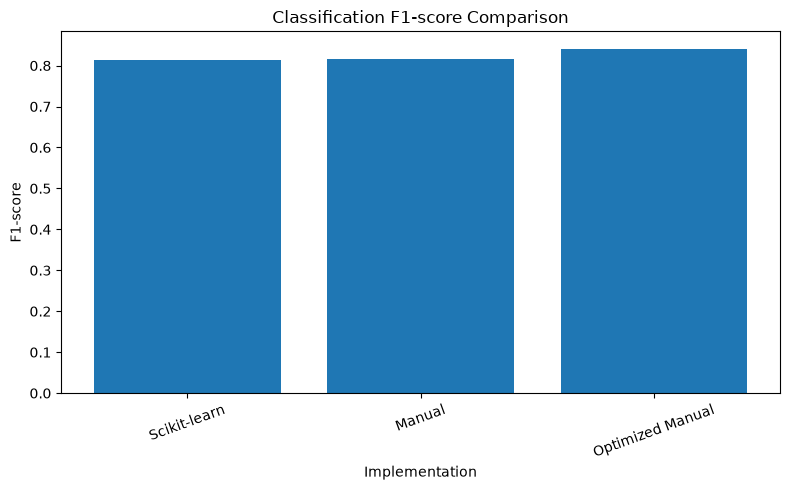

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    final_classification_results["Implementation"],
    final_classification_results["F1"]
)

plt.xlabel("Implementation")
plt.ylabel("F1-score")
plt.title("Classification F1-score Comparison")
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

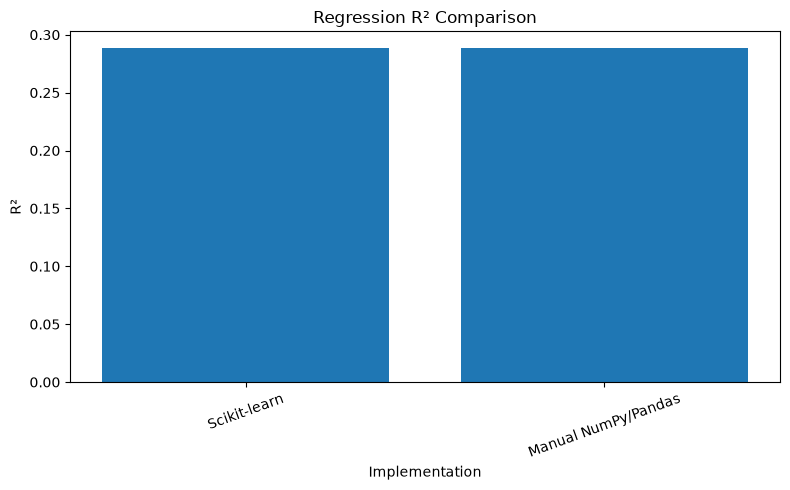

In [67]:
plt.figure(figsize=(8, 5))

plt.bar(
    final_regression_results["Implementation"],
    final_regression_results["R2"]
)

plt.xlabel("Implementation")
plt.ylabel("R²")
plt.title("Regression R² Comparison")
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

In [68]:
runtime_comparison = pd.DataFrame({
    "Model": [
        "Sklearn Linear Regression",
        "Manual Linear Regression",
        "Sklearn Logistic Regression",
        "Manual Logistic Regression",
        "Optimized Manual Logistic Regression"
    ],
    "Training Time (s)": [
        reg_training_time_sklearn,
        reg_training_time_manual,
        cls_training_time_sklearn,
        cls_training_time_manual,
        optimized_training_time
    ],
    "Prediction Time (s)": [
        reg_prediction_time_sklearn,
        reg_prediction_time_manual,
        cls_prediction_time_sklearn,
        cls_prediction_time_manual,
        optimized_prediction_time
    ]
})

display(
    runtime_comparison.round(6)
)

,Model,Training Time (s),Prediction Time (s)
0,Sklearn Linear Regression,0.012404,0.008798
1,Manual Linear Regression,0.001649,0.000086
2,Sklearn Logistic Regression,0.029271,0.008985
3,Manual Logistic Regression,0.402313,0.000253
4,Optimized Manual Logistic Regression,0.665544,0.000147
